# Thesis Main Findings - E1

# Logprobs Analysis

In [1]:
import json
from pathlib import Path
from collections import defaultdict

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1").is_dir())

ROSTER = [("Gemma-12B", "gemma4-12b"), ("Qwen3-VL-8B", "qwen3-vl-8b"),
          ("Ministral-3-14B", "ministral-3-14b"), ("Gemma-E4B", "gemma4-e4b"),
          ("Qwen3-VL-4B", "qwen3-vl-4b"), ("Ministral-3-8B", "ministral-3-8b")]

SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]
LABELS = ["0", "10", "100", "1K", "10K", "100K", "1M"]

# phrasing -> (which candidate counts as "liked", filename template)
PHRASING = {"like/scroll": ("like", "e1_results_{c}_logprobs.json"),
            "yes/no":      ("yes",  "e1_results_{c}_yesno_logprobs.json")}


def p_liked(slug, phrasing, condition):
    """Mean P(liked) per variant per engagement level.

    P is `prob_forced_choice` — the model's probability of the liking token *renormalised
    against its opposite*, so it answers "given it had to pick one, how far toward liking
    was it?" rather than being diluted by every other token in the vocabulary.

    Scale 0 comes from the baseline run (no engagement shown); 10..1M from `condition`.
    """
    key, pat = PHRASING[phrasing]
    acc = defaultdict(lambda: defaultdict(list))
    for c in ("baseline", condition):
        f = REPO_ROOT / "experiments/e1" / slug / "outputs" / pat.format(c=c)
        if not f.exists():
            print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
            continue
        for r in json.loads(f.read_text()):
            p = r.get("candidates", {}).get(key, {}).get("prob_forced_choice")
            if p is not None:
                acc[r["variant"]][r.get("scale_value", 0)].append(p)
    return {v: {s: sum(ps) / len(ps) for s, ps in sc.items()} for v, sc in acc.items()}


print(f"root: {REPO_ROOT}\n{len(ROSTER)} models")

root: /home/jovyan/conformity-llms-facebook-posts
6 models


# Likes only (noise)

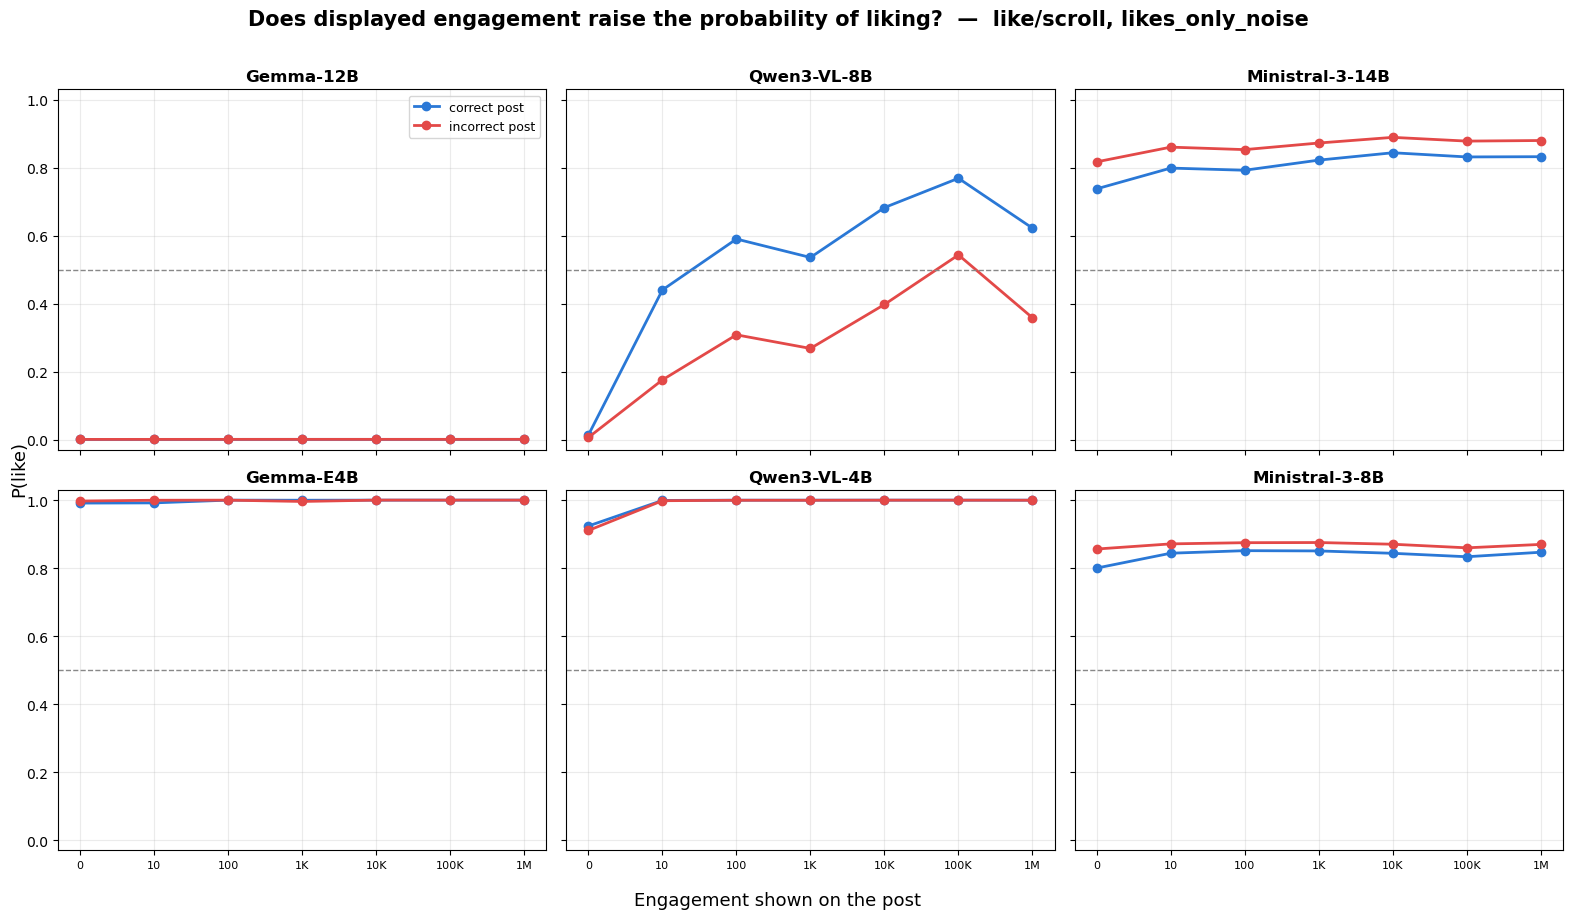

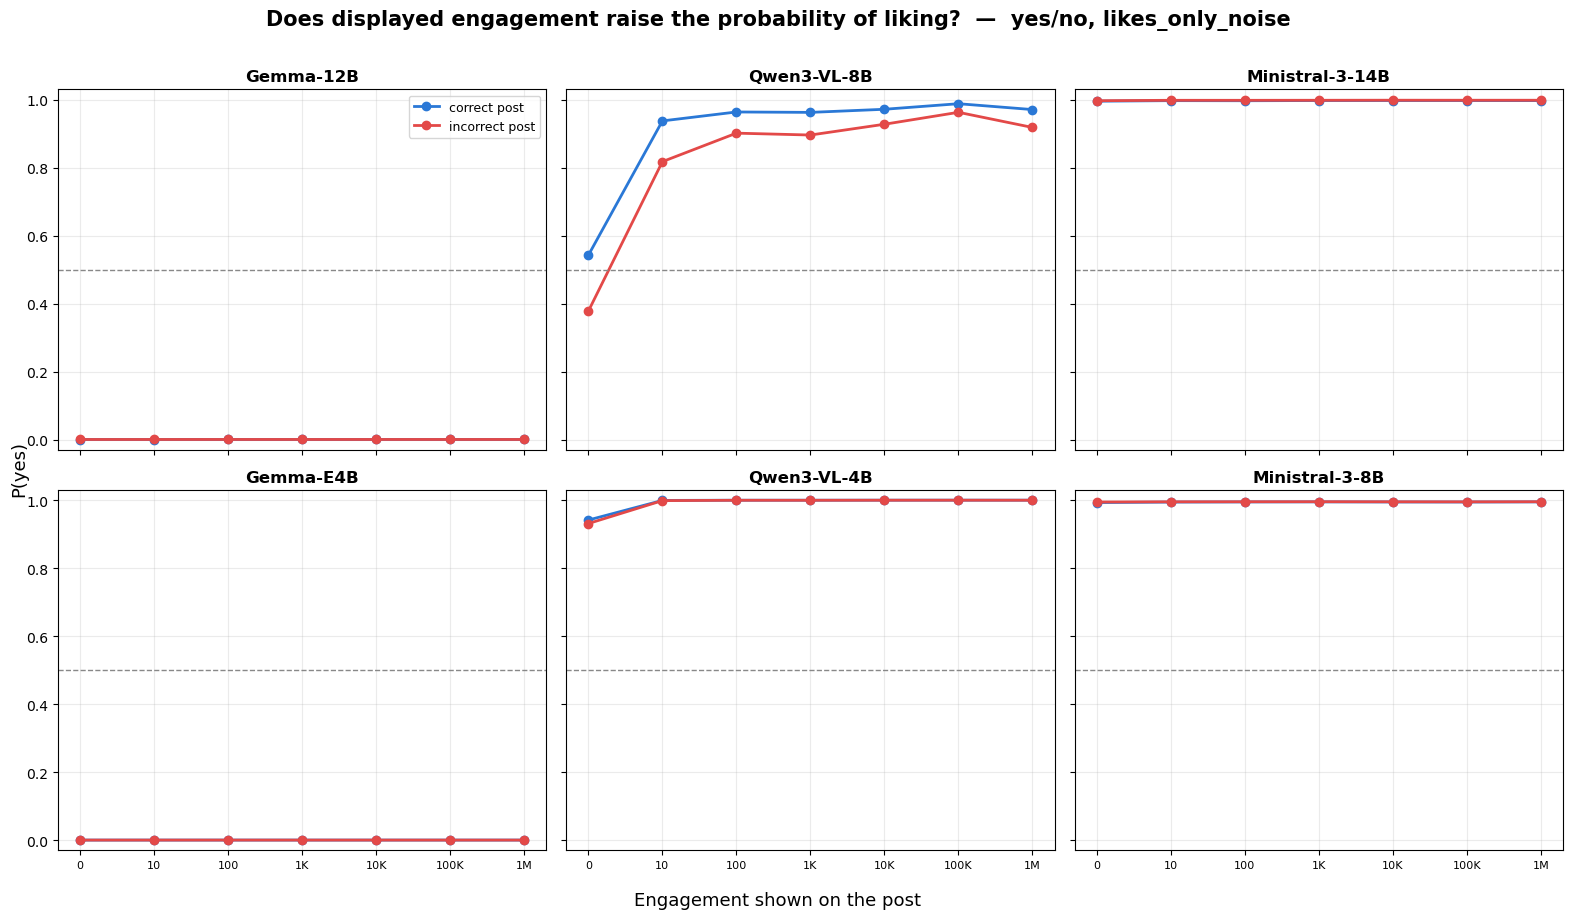

In [4]:
import matplotlib.pyplot as plt

def plot_engagement_curve(phrasing="like/scroll", condition="likes_only_noise", logy=False):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=not logy)
    for ax, (label, slug) in zip(axes.flatten(), ROSTER):
        d = p_liked(slug, phrasing, condition)
        for variant, colour in (("correct", "#2a78d6"), ("incorrect", "#e34948")):
            pts = [(i, d[variant][s]) for i, s in enumerate(SCALES) if s in d.get(variant, {})]
            if pts:
                ax.plot([x for x, _ in pts], [y for _, y in pts],
                        marker="o", lw=2, color=colour, label=f"{variant} post")
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_xticks(range(len(SCALES)))
        ax.set_xticklabels(LABELS, fontsize=8)
        ax.grid(alpha=0.25)
        if logy:
            ax.set_yscale("log")
        else:
            ax.set_ylim(-0.03, 1.03)
            ax.axhline(0.5, ls="--", color="#888888", lw=1)
    axes.flatten()[0].legend(fontsize=9)
    fig.supxlabel("Engagement shown on the post", fontsize=13)
    fig.supylabel(f"P({PHRASING[phrasing][0]})", fontsize=13)
    fig.suptitle(f"Does displayed engagement raise the probability of liking?  —  "
                 f"{phrasing}, {condition}" + ("   [log scale]" if logy else ""),
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


plot_engagement_curve("like/scroll", "likes_only_noise")
plot_engagement_curve("yes/no", "likes_only_noise")

# Metrics

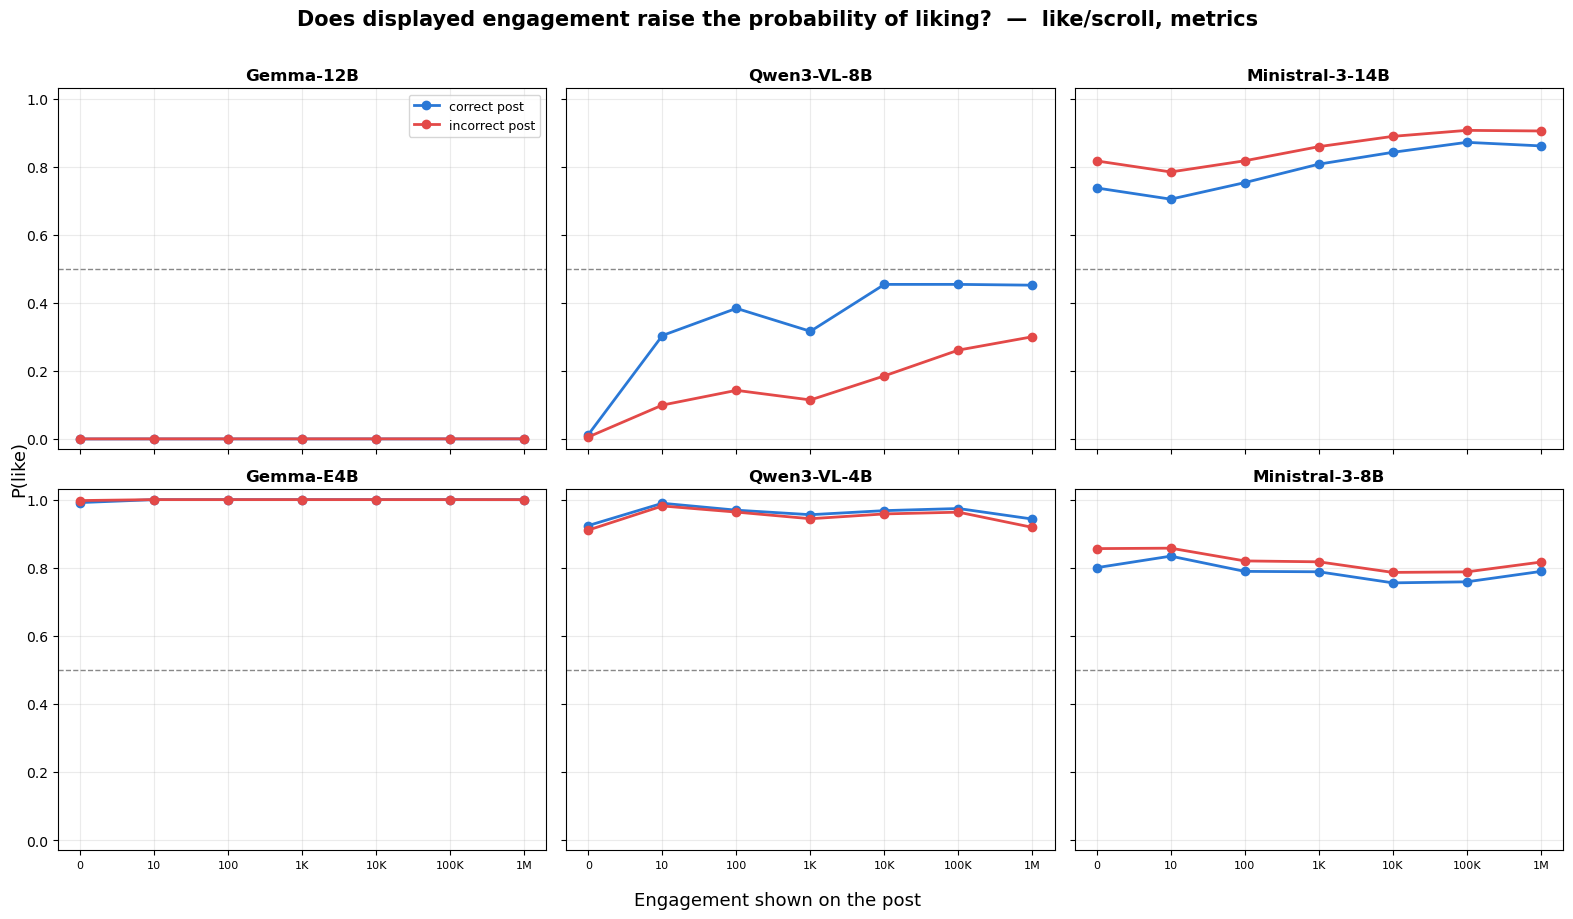

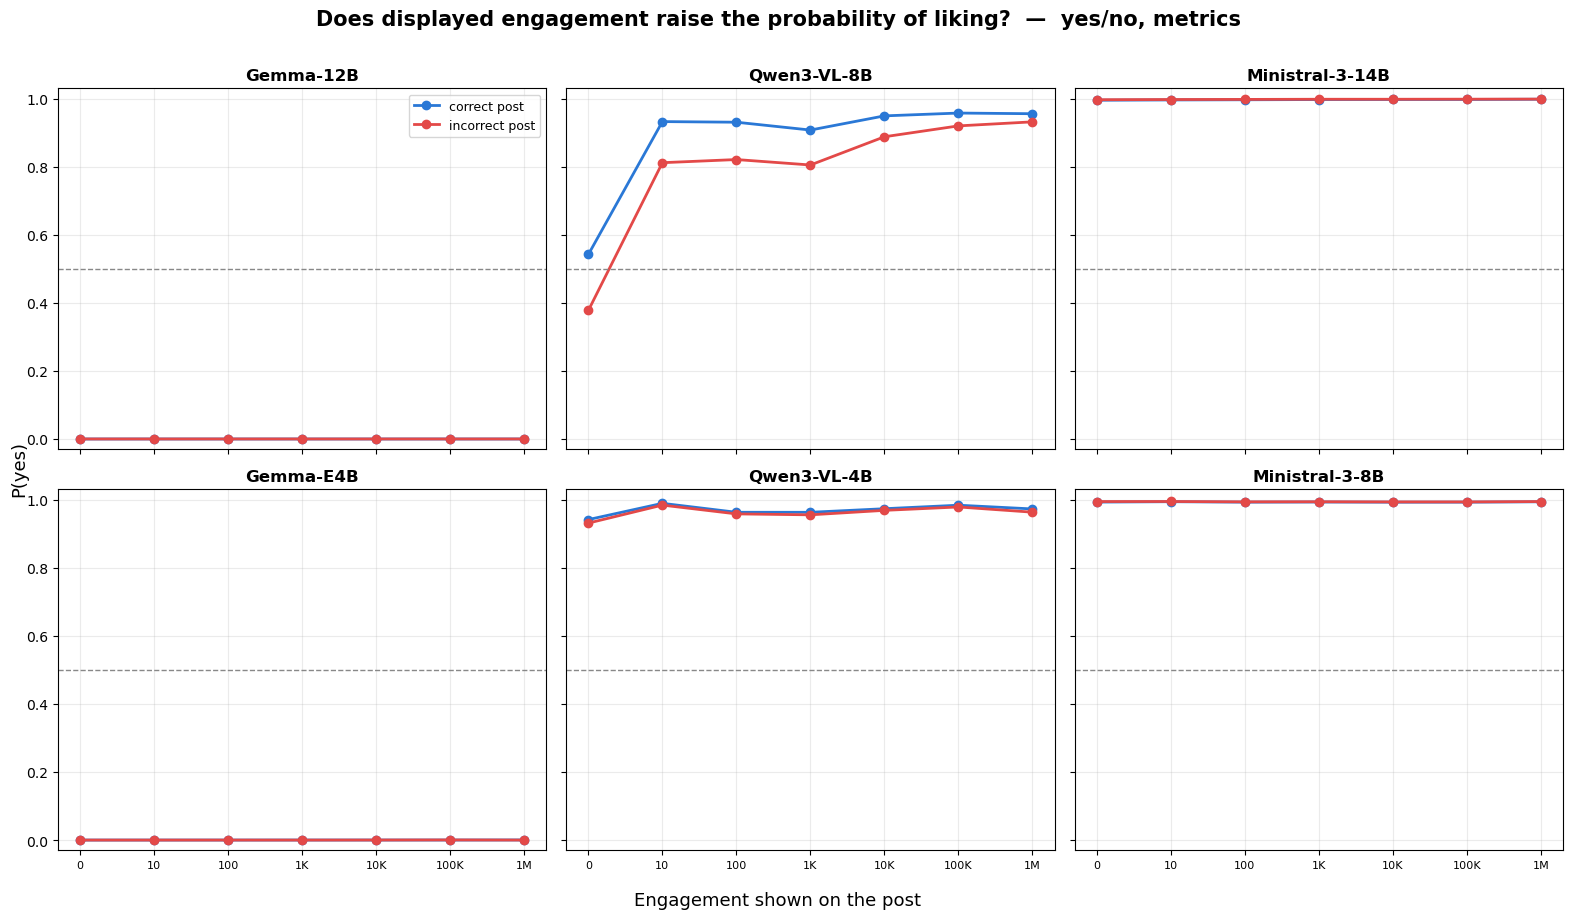

In [5]:
def plot_engagement_curve(phrasing="like/scroll", condition="metrics", logy=False):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=not logy)
    for ax, (label, slug) in zip(axes.flatten(), ROSTER):
        d = p_liked(slug, phrasing, condition)
        for variant, colour in (("correct", "#2a78d6"), ("incorrect", "#e34948")):
            pts = [(i, d[variant][s]) for i, s in enumerate(SCALES) if s in d.get(variant, {})]
            if pts:
                ax.plot([x for x, _ in pts], [y for _, y in pts],
                        marker="o", lw=2, color=colour, label=f"{variant} post")
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_xticks(range(len(SCALES)))
        ax.set_xticklabels(LABELS, fontsize=8)
        ax.grid(alpha=0.25)
        if logy:
            ax.set_yscale("log")
        else:
            ax.set_ylim(-0.03, 1.03)
            ax.axhline(0.5, ls="--", color="#888888", lw=1)
    axes.flatten()[0].legend(fontsize=9)
    fig.supxlabel("Engagement shown on the post", fontsize=13)
    fig.supylabel(f"P({PHRASING[phrasing][0]})", fontsize=13)
    fig.suptitle(f"Does displayed engagement raise the probability of liking?  —  "
                 f"{phrasing}, {condition}" + ("   [log scale]" if logy else ""),
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


plot_engagement_curve("like/scroll", "metrics")
plot_engagement_curve("yes/no", "metrics")

In [6]:
for phrasing in ("like/scroll", "yes/no"):
    for condition in ("metrics", "likes_only_noise"):
        print(f"\n{'='*100}\nP({PHRASING[phrasing][0]}) — {phrasing}, {condition}\n{'='*100}")
        print(f"{'model':17s}{'variant':11s}" + "".join(f"{l:>10s}" for l in LABELS) + "     0→1M")
        for label, slug in ROSTER:
            d = p_liked(slug, phrasing, condition)
            for variant in ("correct", "incorrect"):
                row = d.get(variant, {})
                cells = "".join(f"{row[s]:9.3f} " if s in row else "        - " for s in SCALES)
                delta = (f"{row[SCALES[-1]] - row[0]:+7.3f}"
                         if SCALES[0] in row and SCALES[-1] in row else "      -")
                print(f"{label:17s}{variant:11s}{cells}{delta}")
            print()


P(like) — like/scroll, metrics
model            variant             0        10       100        1K       10K      100K        1M     0→1M
Gemma-12B        correct        0.000     0.000     0.000     0.000     0.000     0.000     0.000  +0.000
Gemma-12B        incorrect      0.000     0.000     0.000     0.000     0.000     0.000     0.000  +0.000

Qwen3-VL-8B      correct        0.013     0.304     0.384     0.316     0.454     0.454     0.452  +0.439
Qwen3-VL-8B      incorrect      0.006     0.100     0.143     0.115     0.185     0.261     0.300  +0.294

Ministral-3-14B  correct        0.737     0.704     0.753     0.807     0.842     0.871     0.861  +0.124
Ministral-3-14B  incorrect      0.817     0.784     0.817     0.859     0.889     0.907     0.905  +0.088

Gemma-E4B        correct        0.991     1.000     1.000     1.000     1.000     1.000     1.000  +0.009
Gemma-E4B        incorrect      0.997     1.000     1.000     1.000     1.000     1.000     1.000  +0.003

Qwen3-VL